In [1]:
import os
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
print(os.getcwd())
import torch

import json
from types import SimpleNamespace

from Model.SolarCLIP_modify import get_recon_unetlike_model_from_args
import Data.Solardataloader_subset as Solardataloader_subset

/mnt/nas/home/huxing/202407/ctf/SolarCLIP_tq


In [2]:
args_path = '/mnt/nas/home/huxing/202407/ctf/SolarCLIP_tq/checkpoints/recon/unetlike_without_merge_expand/magnet-magnet/args.json'
with open(args_path, 'r') as f:
    args = json.load(f)
    args = SimpleNamespace(**args)

for arg in vars(args):
    print(arg, getattr(args, arg))

checkpoint_path = args.checkpoint_path
checkpoint_path += args.token_type + '/'
for i in range(len(args.modal_list)):
    checkpoint_path += args.modal_list[i] + '_'
    for j in range(len(args.enhance_list[i])):
        checkpoint_path += str(args.enhance_list[i][j]) + '_'

checkpoint_path = '/mnt/nas/home/huxing/202407/ctf/SolarCLIP_tq/checkpoints/recon/unetlike_without_merge_expand/magnet-magnet'
model_checkpoint_path = checkpoint_path + '/model/'
logger_checkpoint_path = checkpoint_path + '/logger'

config_dir configs/recon/unetlike/args4.json
batch_size 160
learning_rate 0.1
epochs 1000
test_freq 100
save_freq 100
early_stop 10
device cuda:3
num_workers 0
token_type all embedding
in_channels 1
input_resolution 1024
patch_size 64
width 768
vit_layers 12
transformer_layers 2
hidden_dim 768
norm_type bn1d
output_dim 1
output_size 1024
deprojection_type linear
with_bias True
decoder_modal magnet-magnet
modal_list ['magnet', '0094']
enhance_list [['log1p', 1], ['log1p', 1]]
image_preprocess [1024, 0.5, 90]
weight_type cv-rdbu
embed_state_root checkpoints/recon/0816_test1/SolarCLIP
clip_model_id 200
checkpoint_path /mnt/nas/home/huxing/202407/ctf/SolarCLIP_tq/checkpoints/recon/unetlike_without_merge_expand/
optimizer SGD


In [3]:
ReconModel_dict = torch.load(model_checkpoint_path + 'epoch_39.pt', map_location=torch.device('cuda:2'))['model']
device = torch.device('cuda:3')
SolarReconModel = get_recon_unetlike_model_from_args(args).to(device)
SolarReconModel.load_state_dict(ReconModel_dict)

<All keys matched successfully>

In [4]:
from Data.utils import transfer_date_to_id
import random
import numpy as np

def set_seed(seed):
    random.seed(seed)  # Python 内置随机数生成器
    np.random.seed(seed)  # NumPy 随机数生成器
    torch.manual_seed(seed)  # PyTorch 随机数生成器（CPU）
    torch.cuda.manual_seed(seed)  # PyTorch GPU 随机数生成器
    torch.cuda.manual_seed_all(seed)  # 所有 GPU 的随机数生成器
    torch.backends.cudnn.deterministic = True  # 确保每次结果一致
    torch.backends.cudnn.benchmark = False  # 关闭基准测试以确保一致性

set_seed(0)
start_date = transfer_date_to_id(2020, 6, 30)
end_date = transfer_date_to_id(2024, 6, 30)
print(start_date,end_date)
val_loader = Solardataloader_subset.get_loader_by_time(load_imgs=False,time_step=12*24*60,time_interval=[start_date,end_date],modal_list = args.modal_list, enhance_list = [args.image_preprocess[0],0,0], batch_size = 30, shuffle=True, num_workers=args.num_workers)


5346720 7450560
 magnet has 72889 samples
 0094 has 120206 samples
All modal has 71 samples


In [5]:
from Data.Solardataloader import enhance_funciton
from Solarclip_test import calculate_loss, plot_matrix_with_images
random.seed(0)

with torch.no_grad():
    SolarReconModel = SolarReconModel.eval()
    for i, data in enumerate(val_loader):
        data = data.to(device)
        if args.decoder_modal == 'magnet-0094':
            modal = data[:, 0, :, :, :] 
            modal = enhance_funciton(modal, args.enhance_list[0][0], args.enhance_list[0][1])
            modal_2 = data[:, 1, :, :, :]
            modal_2 = enhance_funciton(modal_2, args.enhance_list[1][0], args.enhance_list[1][1])
        elif args.decoder_modal == '0094-magnet':
            modal = data[:, 1, :, :, :] 
            modal = enhance_funciton(modal, args.enhance_list[1][0], args.enhance_list[1][1])
            modal_2 = data[:, 0, :, :, :]
            modal_2 = enhance_funciton(modal_2, args.enhance_list[0][0], args.enhance_list[0][1])
        elif args.decoder_modal == '0094-0094':
            modal = data[:, 1, :, :, :]
            modal = enhance_funciton(modal, args.enhance_list[1][0], args.enhance_list[1][1])
            modal_2 = modal
        elif args.decoder_modal == 'magnet-magnet':
            modal = data[:, 0, :, :, :]
            modal = enhance_funciton(modal, args.enhance_list[0][0], args.enhance_list[0][1])
            modal_2 = modal
        recon = SolarReconModel(modal)


In [6]:
# from Model.SolarCLIP_modify import get_model_from_args

# clip_args_path = '/mnt/nas/home/huxing/202407/ctf/SolarCLIP_tq/configs/SolarCLIP/args1.json'
# clip_pt_path = '/mnt/nas/home/huxing/202407/ctf/SolarCLIP_tq/checkpoints/recon/0816_test1/SolarCLIP/epoch_200.pt'
# clip_args = json.load(open(clip_args_path, 'r'))
# clip_args = SimpleNamespace(**clip_args)
# for arg in vars(clip_args):
#     print(arg, getattr(clip_args, arg))

In [7]:
# SolarCLIPModel = get_model_from_args(clip_args).to(device)
# SolarCLIPModel.visual_mag.ln_pre.norm 
# SolarCLIPModel.load_state_dict(torch.load(clip_pt_path, map_location=device)['model'])

In [8]:
# feature_0094 = SolarCLIPModel.visual_H(modal_2)
# print(feature_0094.shape)
# print(feature_0094.mean(), feature_0094.std())

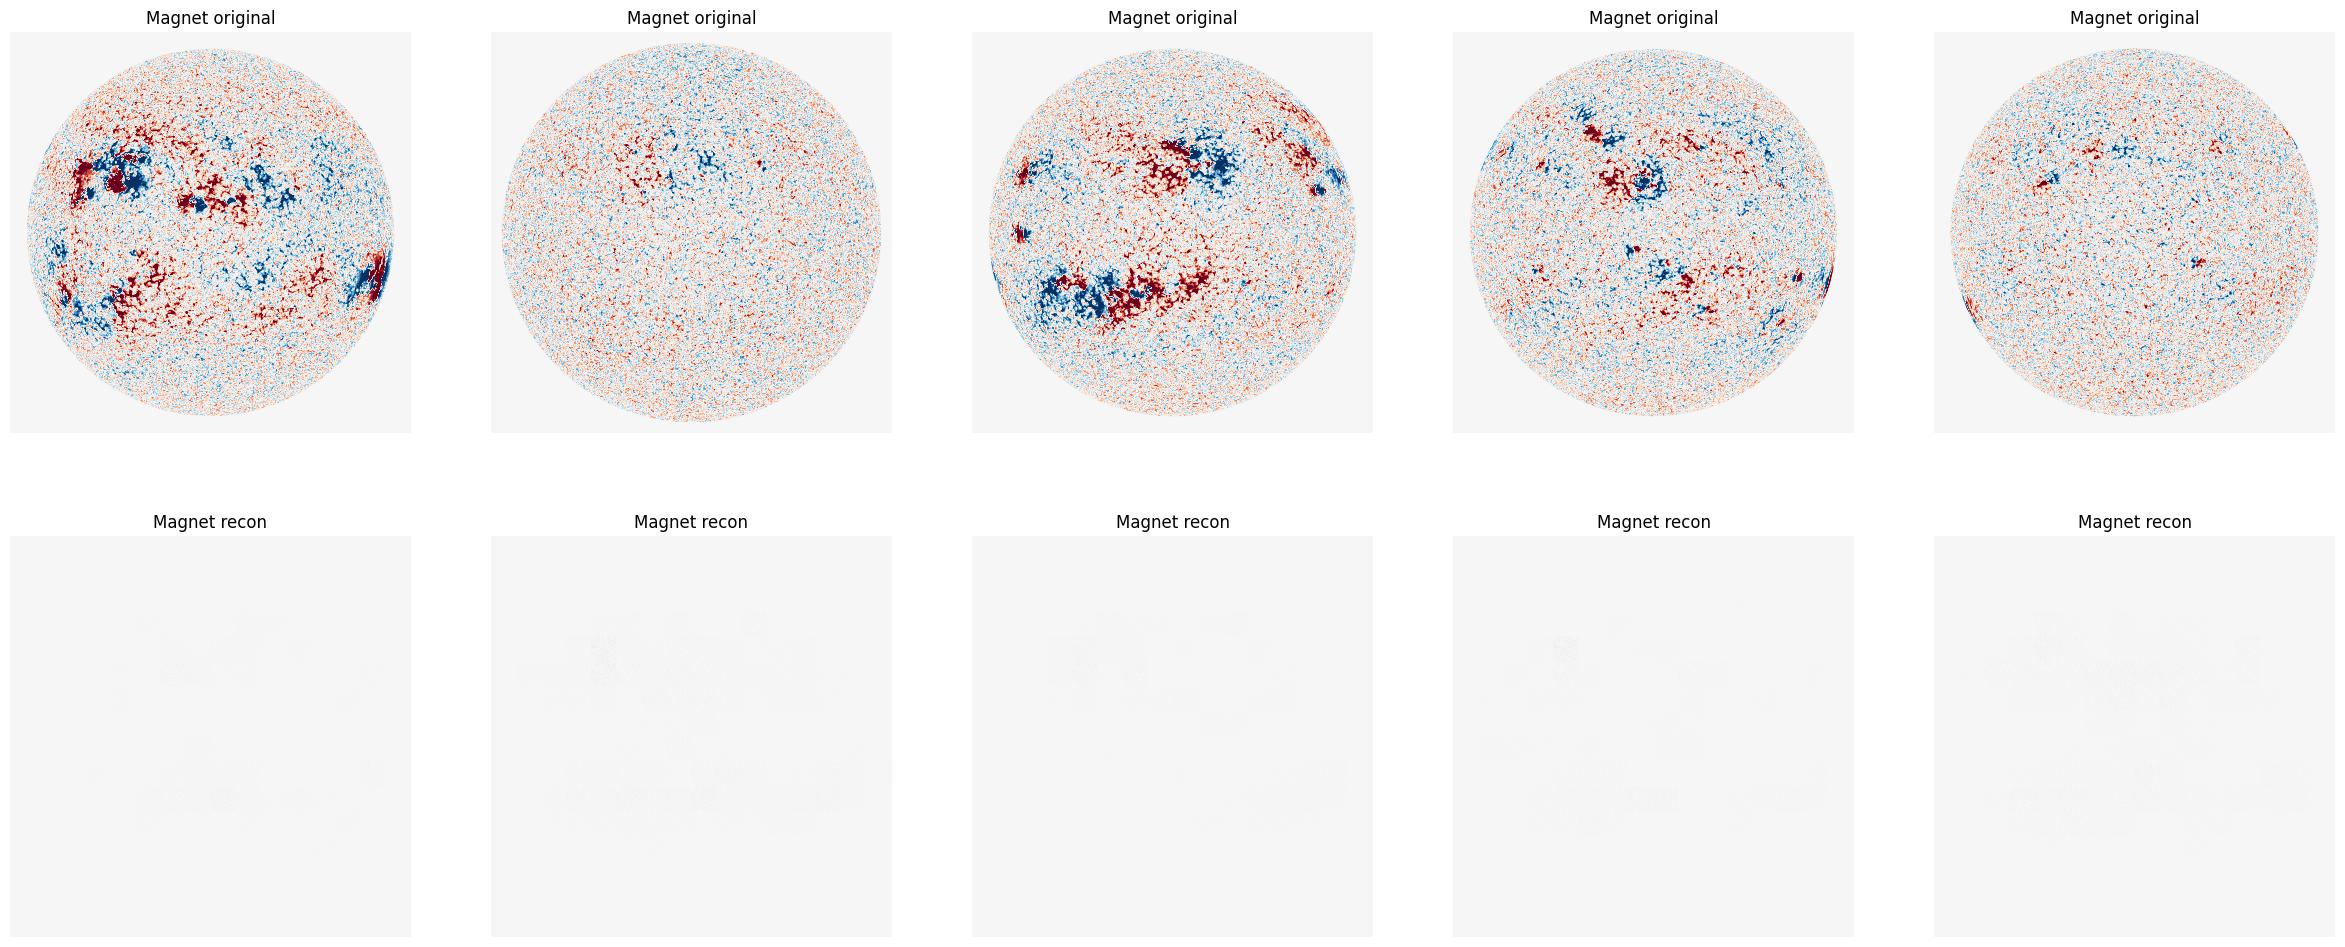

In [13]:
vis_ids = np.arange(5)

mag_image = modal[vis_ids]
mag_image = mag_image.cpu().numpy()

h_image = modal_2[vis_ids]
h_image = h_image.cpu().numpy()

recon_image = recon[vis_ids]
recon_image = recon_image.cpu().numpy()

import matplotlib.pyplot as plt

vmin_magnet = np.min(mag_image)
vmax_magnet = np.max(mag_image)
vmax_magnet = np.max([np.abs(vmin_magnet), np.abs(vmax_magnet)])/2
vmin_magnet = -vmax_magnet
vmin_0094 = 0
vmax_0094 = np.max(h_image)

plt.figure(figsize=(30, 12))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(mag_image[i,0,:,:], cmap='RdBu_r',vmin = vmin_magnet, vmax=vmax_magnet)
    plt.axis('off')
    plt.title('Magnet original')

    plt.subplot(2, 5, i+6)
    plt.imshow(recon_image[i,0,:,:], cmap='RdBu_r',vmin=vmin_magnet, vmax=vmax_magnet)
    plt.axis('off')
    plt.title('Magnet recon')

    # plt.subplot(3, 5, i+1)
    # plt.imshow(mag_image[i,0,:,:], cmap='RdBu_r',vmin=vmin_magnet, vmax=vmax_magnet)
    # plt.axis('off')
    # plt.title('Magne orginal')



In [10]:
print(recon[0,0,510:515,510:515])
print(recon[1,0,510:515,510:515])
print(recon[2,0,510:515,510:515])


tensor([[ 0.0043,  0.0020,  0.0152,  0.0385, -0.0381],
        [ 0.0058,  0.0240,  0.0051, -0.0119, -0.0142],
        [ 0.2501, -0.0089, -0.0329, -0.1528, -0.0119],
        [-0.2229, -0.2719, -0.1256, -0.0500,  0.1230],
        [ 0.4312,  0.2312,  0.0012,  0.0881, -0.0224]], device='cuda:3')
tensor([[ 0.0613,  0.2441,  0.3162, -0.0548, -0.0526],
        [-0.0677,  0.0651, -0.0738,  0.1480,  0.0426],
        [ 0.2738,  0.0224, -0.0331, -0.1941, -0.0142],
        [-0.3135, -0.3110, -0.1735, -0.1014,  0.1581],
        [ 0.5487,  0.2600,  0.0063,  0.1133, -0.0308]], device='cuda:3')
tensor([[-0.0027,  0.0910,  0.1105, -0.0467, -0.0752],
        [-0.0219,  0.0673,  0.0186,  0.0314, -0.0539],
        [ 0.1340, -0.1553, -0.0350, -0.1074, -0.0131],
        [-0.0687, -0.1590, -0.0763, -0.0032,  0.0887],
        [ 0.1378,  0.1160,  0.0071,  0.0694, -0.0144]], device='cuda:3')


In [11]:
print(h_image[0,0,510:515,510:515])
print(h_image[1,0,510:515,510:515])
print(h_image[2,0,510:515,510:515])

[[-1.252763   -1.131402    0.18232156  1.6677068   0.64185387]
 [-1.5475625  -1.3609766   1.2237755   0.40546513 -0.64185387]
 [ 0.26236427  1.0986123   1.0296195   0.18232156 -1.252763  ]
 [-0.74193734  1.0296195   1.3609766   0.53062826 -0.47000366]
 [ 1.2237755   1.252763    0.64185387  0.33647224 -1.0296195 ]]
[[ 2.1162555   1.1939225   0.95551145 -0.09531018  0.95551145]
 [ 1.9315214   1.7227666  -0.47000366  0.5877867   0.64185387]
 [ 2.3418057   1.1939225  -1.131402   -0.47000366 -0.74193734]
 [ 1.1939225   0.91629076 -0.53062826 -1.0986123  -1.9459102 ]
 [-0.64185387  0.74193734 -0.9932518   0.8329091   1.5892352 ]]
[[ 3.763523    2.85647     2.6173959   1.252763    0.95551145]
 [ 4.000034    3.94739     3.6082115   2.2192035   0.6931472 ]
 [ 2.091864    2.1972246   1.7917595   1.8870697  -0.95551145]
 [-1.2809339   0.6931472   0.53062826  2.533697    3.0864866 ]
 [-1.131402   -1.3862944  -0.7884574  -0.33647224 -0.95551145]]


Text(0.5, 1.0, 'Val weight mse\n Last 10% mean: 0.05800629')

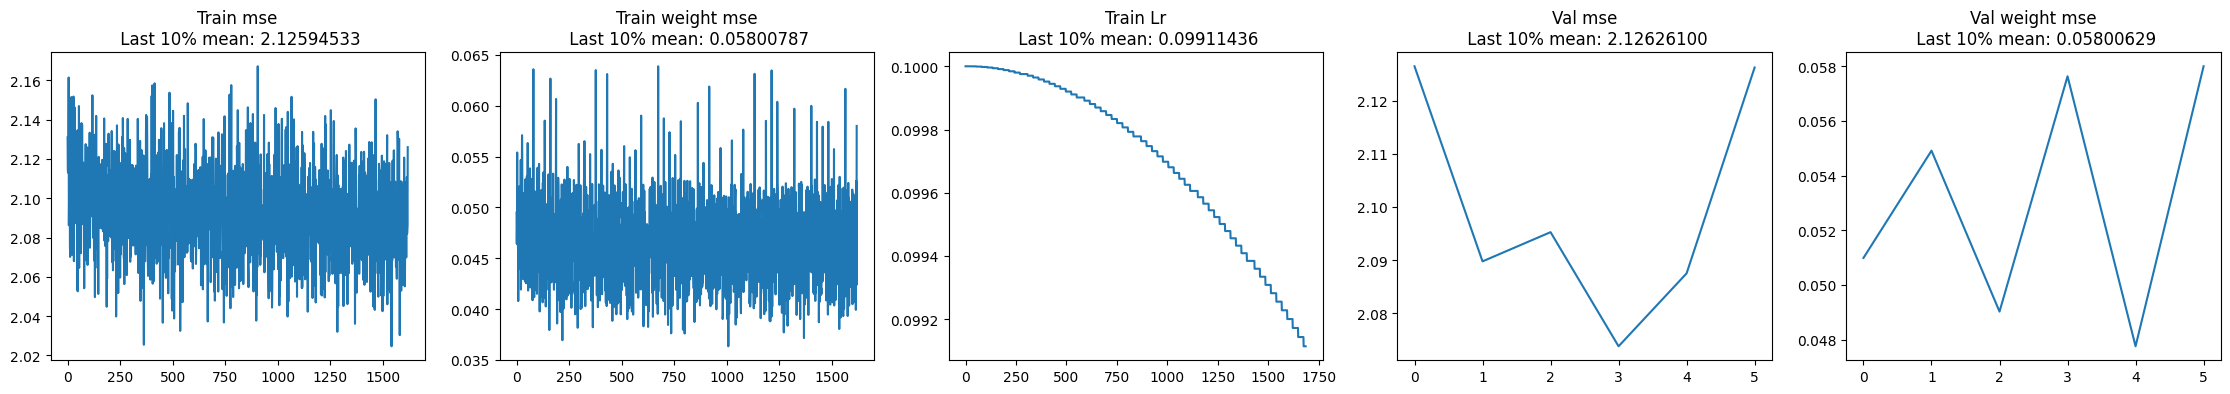

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

with open(logger_checkpoint_path + '/logger_train_mse.pkl', 'rb') as f:
    logger_train_mse = pickle.load(f)
with open(logger_checkpoint_path + '/logger_train_weight_mse.pkl', 'rb') as f:
    logger_train_weight_mse = pickle.load(f)

with open(logger_checkpoint_path + '/logger_val_mse.pkl', 'rb') as f:
    logger_val_mse = pickle.load(f)
with open(logger_checkpoint_path + '/logger_val_weight_mse.pkl', 'rb') as f:
    logger_val_weight_mse = pickle.load(f)

with open(logger_checkpoint_path + '/logger_lr.pkl', 'rb') as f:
    logger_lr = pickle.load(f)

# visualization_num = int(len(logger_val_loss)*0.1)
visualization_num = 1


plt.figure(figsize=(28, 4))

plt.subplot(1,5,1)
plt.plot(logger_train_mse)
train_loss_last = np.mean(logger_train_mse[-visualization_num:])
plt.title('Train mse\n Last 10% mean: {:.8f}'.format(train_loss_last))

plt.subplot(1,5,2)
plt.plot(logger_train_weight_mse)
train_loss_inner_last = np.mean(logger_train_weight_mse[-visualization_num:])
plt.title('Train weight mse\n Last 10% mean: {:.8f}'.format(train_loss_inner_last))

plt.subplot(1,5,3)
plt.plot(logger_lr)
train_acc_last = np.mean(logger_lr[-visualization_num:])
plt.title('Train Lr\n Last 10% mean: {:.8f}'.format(train_acc_last))

plt.subplot(1,5,4)
plt.plot(logger_val_mse)
val_loss_last = np.mean(logger_val_mse[-visualization_num:])
plt.title('Val mse\n Last 10% mean: {:.8f}'.format(val_loss_last))

plt.subplot(1,5,5)
plt.plot(logger_val_weight_mse)
val_loss_inner_last = np.mean(logger_val_weight_mse[-visualization_num:])
plt.title('Val weight mse\n Last 10% mean: {:.8f}'.format(val_loss_inner_last))



